In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/UpdatedResumeDataSet.csv")

In [ ]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
df.columns


Index(['Category', 'Resume'], dtype='object')

In [ ]:
df.isnull().sum()

,0
Category,0
Resume,0


In [ ]:
df['Resume'][0][:1000]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [ ]:
import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r'http\S+',' ',text)
  text=re.sub(r'[^a-zA-Z]',' ',text)
  text=re.sub(r'\s+',' ',text)
  return text.strip()
df['Clean_Resume']=df['Resume'].apply(clean_text)

In [ ]:
df.head()

,Category,Resume,Clean_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may to may b e uit rgpv data...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


In [ ]:
skills=[
    'python','java','sql','machine learning','deep learning','data analysis','power bi','excel','tensorflow','pytorch','aws','docker','git','communication'
]

In [ ]:
def extract_skills(text):
  found_skills=[]
  for skill in skills:
    if skill in text:
      found_skills.append(skill)
  return found_skills
df['Skills']=df['Clean_Resume'].apply(extract_skills)

In [ ]:
df[['Category','Skills']].head(10)

,Category,Skills
0,Data Science,"[python, java, sql, machine learning, deep lea..."
1,Data Science,"[python, machine learning, aws, git]"
2,Data Science,"[python, java, sql, machine learning, deep lea..."
3,Data Science,"[python, sql, machine learning, deep learning,..."
4,Data Science,"[python, java, data analysis]"
5,Data Science,"[python, machine learning, excel]"
6,Data Science,"[python, machine learning, excel]"
7,Data Science,"[python, java, sql, machine learning, deep lea..."
8,Data Science,"[python, sql, machine learning, deep learning]"
9,Data Science,"[python, machine learning, data analysis, aws,..."


In [ ]:
job_description="""
    We are hiring an AI/ML Engineer.
    Required Skills:
    Python Machine Learning Deep Learning SQL AWS
    """


In [ ]:
cleaned_job_description = clean_text(job_description)
job_description = cleaned_job_description
job_description

'we are hiring an ai ml engineer required skills python machine learning deep learning sql aws'

In [ ]:
required_skills=extract_skills(job_description)
required_skills

['python', 'sql', 'machine learning', 'deep learning', 'aws']

In [ ]:
'python' in job_description

True

In [ ]:
scores=[]
for resume in df['Clean_Resume']:
  vectorizer=TfidfVectorizer()
  tfidf=vectorizer.fit_transform([job_description,resume])
  similarity=cosine_similarity(tfidf[0:1],tfidf[1:2])[0][0]
  scores.append(similarity)


In [ ]:
df['Scores']=scores
df[['Category','Scores']].head(10)

,Category,Scores
0,Data Science,0.039525
1,Data Science,0.061984
2,Data Science,0.081760
3,Data Science,0.049020
4,Data Science,0.008440
5,Data Science,0.073098
6,Data Science,0.101703
7,Data Science,0.156124
8,Data Science,0.171748
9,Data Science,0.057371


In [ ]:
ranked_df=df.sort_values(by='Scores',ascending=False)
ranked_df[['Category','Scores']].head(10)

,Category,Scores
38,Data Science,0.171748
8,Data Science,0.171748
18,Data Science,0.171748
28,Data Science,0.171748
37,Data Science,0.156124
7,Data Science,0.156124
17,Data Science,0.156124
27,Data Science,0.156124
719,Database,0.104302
730,Database,0.104302


In [ ]:
def skill_gap(candidate_skills,required_skills):
  candidate_skills=set(candidate_skills)
  required_skills=set(required_skills)
  gap=required_skills-candidate_skills
  return list(gap)

In [ ]:
df['missing_skills']=df['Skills'].apply(lambda x:skill_gap(x,required_skills))

In [ ]:
best_candidate=ranked_df.iloc[0]
best_candidate

,38
Category,Data Science
Resume,Personal Skills â¢ Ability to quickly grasp t...
Clean_Resume,personal skills ability to quickly grasp techn...
Skills,"[python, sql, machine learning, deep learning]"
Scores,0.171748


In [ ]:
df['Score_percent']=(df['Scores']*100).round(2)

In [ ]:
ranked_df=df.sort_values(by='Score_percent',ascending=False)
ranked_df[['Category','Score_percent']].head(10)

,Category,Score_percent
8,Data Science,17.17
38,Data Science,17.17
18,Data Science,17.17
28,Data Science,17.17
17,Data Science,15.61
27,Data Science,15.61
37,Data Science,15.61
7,Data Science,15.61
719,Database,10.43
741,Database,10.43


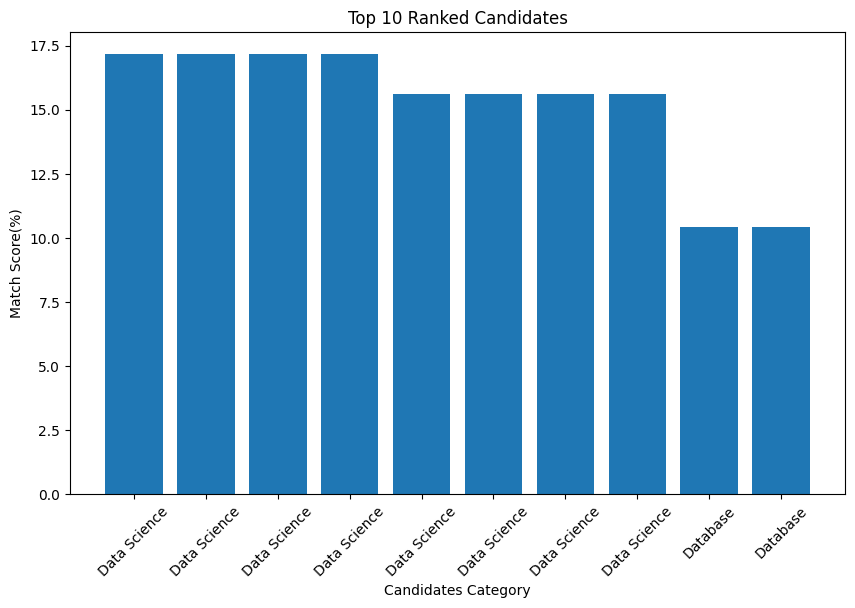

In [ ]:
  import matplotlib.pyplot as plt
  top10 = ranked_df.head(10)
  plt.figure(figsize=(10,6))
  plt.bar(
      range(len(top10)),
      top10['Score_percent']
  )
  plt.xticks(
      range(len(top10)),
      top10['Category'],
      rotation=45
  )
  plt.ylabel("Match Score(%)")
  plt.xlabel("Candidates Category")
  plt.title("Top 10 Ranked Candidates")
  plt.show()

In [25]:
job_descriptions = {

    "AI_ML_Engineer":
    """
    Python Machine Learning Deep Learning SQL AWS
    """,

    "Data_Scientist":
    """
    Python Machine Learning Statistics SQL Deep Learning
    """,

    "Data_Analyst":
    """
    SQL Excel Power BI Data Analysis Statistics
    """,

    "Java_Developer":
    """
    Java Spring Boot MySQL Git
    """,

    "Python_Developer":
    """
    Python Django Flask SQL Git
    """
}

In [26]:
selected_role = "Data_Scientist"

job_description = clean_text(
    job_descriptions[selected_role]
)

required_skills = extract_skills(
    job_description
)

In [28]:
scores = []

for resume in df['Clean_Resume']:

    vectorizer = TfidfVectorizer()

    tfidf = vectorizer.fit_transform(
        [job_description, resume]
    )

    similarity = cosine_similarity(
        tfidf[0:1],
        tfidf[1:2]
    )[0][0]

    scores.append(similarity)

In [29]:
df['score_percent'] = (
    np.array(scores) * 100
).round(2)

In [30]:
ranked_df = df.sort_values(
    by='score_percent',
    ascending=False
)

ranked_df.head(10)

,Category,Resume,Clean_Resume,Skills,Scores,missing_skills,Score_percent,score_percent
28,Data Science,Personal Skills â¢ Ability to quickly grasp t...,personal skills ability to quickly grasp techn...,"[python, sql, machine learning, deep learning]",0.171748,[aws],17.17,24.81
18,Data Science,Personal Skills â¢ Ability to quickly grasp t...,personal skills ability to quickly grasp techn...,"[python, sql, machine learning, deep learning]",0.171748,[aws],17.17,24.81
38,Data Science,Personal Skills â¢ Ability to quickly grasp t...,personal skills ability to quickly grasp techn...,"[python, sql, machine learning, deep learning]",0.171748,[aws],17.17,24.81
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...,personal skills ability to quickly grasp techn...,"[python, sql, machine learning, deep learning]",0.171748,[aws],17.17,24.81
27,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,education details b tech rayat and bahra insti...,"[python, java, sql, machine learning, deep lea...",0.156124,[aws],15.61,22.09
37,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,education details b tech rayat and bahra insti...,"[python, java, sql, machine learning, deep lea...",0.156124,[aws],15.61,22.09
17,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,education details b tech rayat and bahra insti...,"[python, java, sql, machine learning, deep lea...",0.156124,[aws],15.61,22.09
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,education details b tech rayat and bahra insti...,"[python, java, sql, machine learning, deep lea...",0.156124,[aws],15.61,22.09
36,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...,skills python tableau data visualization r stu...,"[python, machine learning, excel]",0.101703,"[sql, deep learning, aws]",10.17,14.22
26,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...,skills python tableau data visualization r stu...,"[python, machine learning, excel]",0.101703,"[sql, deep learning, aws]",10.17,14.22
